*heteroTests tutorial series — [01. Detecting heteroscedasticity](01-detecting-heteroscedasticity.ipynb) · [02. Remediation](02-remediating-heteroscedasticity.ipynb) · [03. Modern & scalable diagnostics](03-modern-and-scalable.ipynb) · [04. Group-wise variance tests](04-group-wise-variance.ipynb) · [05. Time series & ARCH effects](05-time-series-arch.ipynb) · **06. Choosing a test: a power study***


# Choosing a Test: A Power Study

**Which heteroscedasticity test should you run? It depends on the pattern.**

---

There is no uniformly most powerful heteroscedasticity test. Each one builds an
auxiliary model of the variance, and a test is powerful exactly when that model
matches the *shape* of the true variance. This notebook runs a small Monte-Carlo
study to make the trade-offs concrete and to distil a practical decision guide.

We compare six tests against four variance shapes, plus a homoscedastic control
to confirm that none of them over-rejects.


In [1]:
library(heteroTests)
ht_set_log_level("SILENT")  # keep simulation loops quiet
library(ggplot2)
theme_set(theme_minimal(base_size = 12))
options(digits = 4)


Warning message:
"package 'ggplot2' was built under R version 4.5.3"


## 1. The design

A single regressor $x \sim U(1,4)$, mean model $y = 1 + 1.5x + \varepsilon$, and
five variance regimes for $\operatorname{sd}(\varepsilon)$:

| Regime | $\operatorname{sd}(\varepsilon_i)$ | Meaning |
|--------|-----|---------|
| `none` | $1$ | homoscedastic (calibration / size check) |
| `linear` | $0.6 + 0.25\,x$ | variance grows linearly with $x$ |
| `quadratic` | $0.6 + 0.06\,x^2$ | variance grows with $x^2$ |
| `step` | $0.7$ or $1.5$ either side of $\operatorname{median}(x)$ | two-regime variance |

Effect sizes are deliberately modest ($n = 80$) so that the tests separate
rather than all hitting 100%.


In [2]:
gen <- function(n, pattern) {
  x <- runif(n, 1, 4)
  sd <- switch(pattern,
    none      = rep(1, n),
    linear    = 0.6 + 0.25 * x,
    quadratic = 0.6 + 0.06 * x^2,
    step      = ifelse(x > median(x), 1.5, 0.7))
  data.frame(y = 1 + 1.5 * x + rnorm(n, sd = sd), x = x)
}

run_test <- function(t, m, d) tryCatch(switch(t,
    White   = performWhiteTest(m, d),   `Breusch-Pagan` = performBPTest(m, d),
    Koenker = performKoenkerTest(m, d), `Goldfeld-Quandt` = performGQTest(m, d, order_by = "x"),
    Glejser = performGlejserTest(m, d, "x"), Harvey = performHarveyTest(m))$p.value,
  error = function(e) NA_real_)


## 2. Running the study

For each (test, regime) cell we record the proportion of 200 replications that
reject at the 5% level. For `none` this is the empirical **size** (should be
$\approx 5$%); for the others it is **power**.


In [3]:
tests    <- c("White", "Breusch-Pagan", "Koenker", "Goldfeld-Quandt", "Glejser", "Harvey")
patterns <- c("none", "linear", "quadratic", "step")
set.seed(9); reps <- 200; n <- 80
res <- matrix(0, length(tests), length(patterns), dimnames = list(tests, patterns))
for (p in patterns) for (i in seq_len(reps)) {
  d <- gen(n, p); m <- lm(y ~ x, data = d)
  for (t in tests) {
    pv <- run_test(t, m, d)
    if (!is.na(pv) && pv < 0.05) res[t, p] <- res[t, p] + 1
  }
}
res <- round(100 * res / reps, 1)
res


,none,linear,quadratic,step
White,3.5,39.5,71.0,75.5
Breusch-Pagan,5.0,54.5,87.0,96.5
Koenker,4.0,52.5,84.5,88.0
Goldfeld-Quandt,8.5,61.0,87.0,99.5
Glejser,4.5,51.5,83.5,91.5
Harvey,5.0,23.0,39.0,68.0


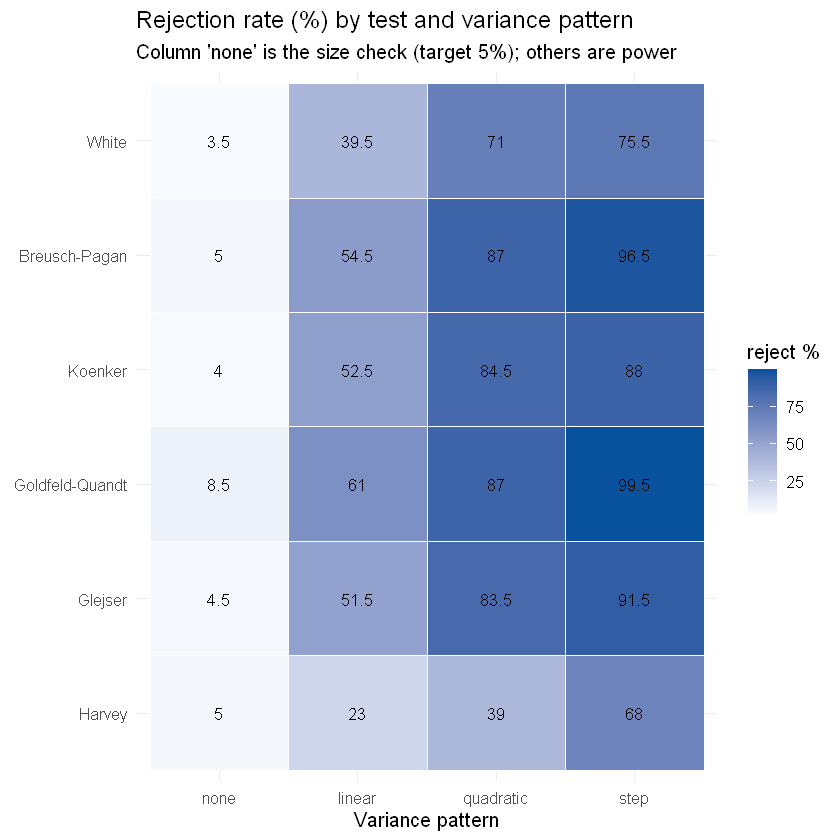

In [4]:
long <- data.frame(
  test    = rep(rownames(res), times = ncol(res)),
  pattern = rep(colnames(res), each = nrow(res)),
  value   = as.vector(res))
long$test    <- factor(long$test, levels = rev(rownames(res)))
long$pattern <- factor(long$pattern, levels = colnames(res))
ggplot(long, aes(pattern, test, fill = value)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = value), size = 3.5) +
  scale_fill_gradient(low = "#f7fbff", high = "#08519c", name = "reject %") +
  labs(x = "Variance pattern", y = NULL,
       title = "Rejection rate (%) by test and variance pattern",
       subtitle = "Column 'none' is the size check (target 5%); others are power")


## 3. Reading the results

**Size (`none` column).** Every test is close to the nominal 5%, with
Goldfeld--Quandt running slightly liberal --- none is broken.

**Power (other columns).**

- **Goldfeld--Quandt** is the strongest whenever the ordering variable drives the
  variance (`linear`, `step`): splitting the sample on $x$ aligns perfectly with
  the true pattern.
- **Breusch--Pagan, Koenker and Glejser** form a strong, reliable middle: they
  test the variance directly against $x$ and do well across all shapes.
- **White** is the most general test --- it makes no assumption about the form ---
  but that generality costs degrees of freedom (it includes squares and
  cross-products), so it is *less* powerful against these simple, known shapes.
- **Harvey** trails on additive variance: its log-variance auxiliary regression
  is tuned to multiplicative/exponential heteroscedasticity, which is not what
  these regimes generate.

The ranking is not a quality ordering --- it is a *matching* problem. The best
test is the one whose auxiliary model resembles the variance you actually have.


## 4. A practical decision guide

| If you... | Prefer |
|-----------|--------|
| suspect variance tied to one ordered covariate | **Goldfeld--Quandt** (order by it) |
| suspect variance linear in the regressors | **Breusch--Pagan** / **Koenker** |
| are unsure about normality | **Koenker** (studentized) |
| suspect multiplicative / exponential variance | **Harvey** or **Park** (log scale) |
| have no prior idea of the form | **White** (general), then follow up |
| have grouped data | the group-wise tests (notebook 4) |

And in every case the cheapest insurance is to run two or three complementary
tests, exactly as `runHeteroTests()` does. A disagreement among them is itself
informative --- it points at the *shape* of the problem, as the White-vs-rest
split did in notebook 1.

---


In [5]:
sessionInfo()


R version 4.5.1 (2025-06-13 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_United Kingdom.utf8 
[2] LC_CTYPE=English_United Kingdom.utf8   
[3] LC_MONETARY=English_United Kingdom.utf8
[4] LC_NUMERIC=C                           
[5] LC_TIME=English_United Kingdom.utf8    

time zone: Europe/Lisbon
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ggplot2_4.0.2     heteroTests_0.6.5

loaded via a namespace (and not attached):
 [1] crayon_1.5.3       vctrs_0.7.2        cli_3.6.5          rlang_1.1.7       
 [5] generics_0.1.4     S7_0.2.0           textshaping_1.0.4  jsonlite_2.0.0    
 [9] labeling_0.4.3     glue_1.8.0         htmltools_0.5.8.1  IRdisplay_1.1     
[13] IRkernel_1.3.2     ragg_1.5.0         scales_1.4.0       grid_4.5.1        
[17] tibble_3.3.1       eva